# Samsung Global Sales - Предсказание статуса возврата (CP2)

**Задача:** мультиклассовая классификация `return_status` (Kept / Returned / Exchanged)  
**Датасет:** Samsung Global Sales Dataset (Kaggle), 15 500 строк, 28 признаков  
**Целевая метрика:** F1-macro


## Источник данных

**Датасет:** [Samsung Global Sales Dataset](https://www.kaggle.com/datasets/muhammadehsan02/samsung-global-sales-dataset) — Kaggle.

**Почему выбран:**
- Реальная бизнес-задача по предсказанию статуса возврата товара
- Подходит по объему для обучения нескольких ML-моделей
- Наличие дисбаланса классов (~86/9/5%) - интересная задача, требующая специальных техник (class_weight, F1-macro)

**Описание:** 15 500 транзакций продаж Samsung за 2021–2024 гг. по 20+ странам. Каждая строка - это одна продажа с информацией о продукте, покупателе, канале продаж и итоговом статусе возврата.

In [287]:
import sys
print(sys.executable)

c:\Users\я\Documents\ML\.venv\Scripts\python.exe


In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [289]:
df = pd.read_csv('../data/raw/samsung_global_sales_dataset.csv')
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (15500, 28)


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [290]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  str    
 1   sale_date               15500 non-null  str    
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  str    
 4   month                   15500 non-null  str    
 5   country                 15500 non-null  str    
 6   region                  15500 non-null  str    
 7   city                    15500 non-null  str    
 8   product_name            15500 non-null  str    
 9   category                15500 non-null  str    
 10  storage                 7651 non-null   str    
 11  color                   15500 non-null  str    
 12  is_5g                   15500 non-null  str    
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null  int64  
 

In [291]:
df.describe(include='all')

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
count,15500,15500,15500.000000,15500,15500,15500,15500,15500,15500,15500,...,15500,15500.000000,1.550000e+04,15500,15500,15500,15500,6127,11249.000000,15500
unique,15500,1461,NaN,4,12,52,8,555,73,11,...,44,NaN,NaN,7,8,5,5,5,NaN,3
top,SAMS-00000001,2022-01-12,NaN,Q2,June,Norway,Europe,Singapore,Samsung Galaxy Tab S9 FE,Galaxy S,...,EUR,NaN,NaN,E-commerce Platform,Cash,Government,25–34,Android (Samsung),NaN,Kept
freq,1,23,NaN,3986,1376,328,5327,270,250,2316,...,2693,NaN,NaN,2272,1999,3140,3227,1344,NaN,13315
mean,NaN,NaN,2022.511935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1054.528710,1.595853e+06,NaN,NaN,NaN,NaN,NaN,3.743515,NaN
std,NaN,NaN,1.113496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4062.232887,1.092157e+07,NaN,NaN,NaN,NaN,NaN,0.721258,NaN
min,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.790000,6.080000e+00,NaN,NaN,NaN,NaN,NaN,2.500000,NaN
25%,NaN,NaN,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.360000,1.199072e+03,NaN,NaN,NaN,NaN,NaN,3.100000,NaN
50%,NaN,NaN,2023.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.650000,7.813940e+03,NaN,NaN,NaN,NaN,NaN,3.700000,NaN
75%,NaN,NaN,2024.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,110.000000,9.126992e+04,NaN,NaN,NaN,NaN,NaN,4.400000,NaN


In [292]:
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

storage               7849
previous_device_os    9373
customer_rating       4251
dtype: int64


In [293]:
df['customer_rating'] = df.groupby('category')['customer_rating'].transform(lambda x: x.fillna(x.median()))
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())
df['previous_device_os'] = df['previous_device_os'].fillna('Unknown')
df['storage'] = df['storage'].fillna('Unknown')
print("Пропуски после обработки:", df.isnull().sum().sum())

Пропуски после обработки: 0


**Вывод:** пропуски обработаны корректно:
- `customer_rating` заполнен медианой по категории продукта
- `previous_device_os` заполнен значением `'Unknown'`
- `storage` заполнен значением `'Unknown'`
- После обработки пропусков в данных не осталось

In [294]:
Q99_price = df['unit_price_usd'].quantile(0.99)
Q99_revenue = df['revenue_usd'].quantile(0.99)
print(f"99-й перцентиль цены: {Q99_price}, выручки: {Q99_revenue}")
df = df[(df['unit_price_usd'] <= Q99_price) & (df['revenue_usd'] <= Q99_revenue)]
print(f"Размер после удаления выбросов: {df.shape}")

99-й перцентиль цены: 4772.499100000001, выручки: 10765.368700000006
Размер после удаления выбросов: (15240, 28)


**Вывод:** удалены строки с `unit_price_usd` > 4772$ и `revenue_usd` > 10765$. 
Потеряно 260 строк из 15 500 (~1.7%)

In [295]:
print(f"Уникальных sale_id: {df['sale_id'].nunique()}, всего строк: {len(df)}")
duplicates = df.duplicated().sum()
print(f"Полных дубликатов строк: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()

Уникальных sale_id: 15240, всего строк: 15240
Полных дубликатов строк: 0


**Вывод:** полных дублей не обнаружено. Каждая строка — уникальная транзакция (подтверждается уникальностью `sale_id`).

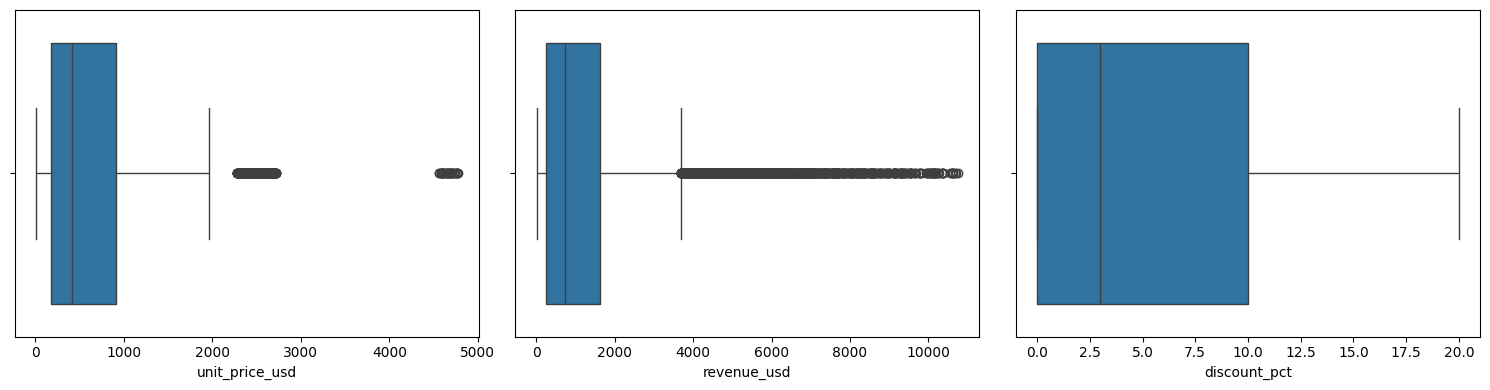

In [296]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x='unit_price_usd', ax=axes[0])
sns.boxplot(data=df, x='revenue_usd', ax=axes[1])
sns.boxplot(data=df, x='discount_pct', ax=axes[2])
plt.tight_layout()
plt.show()

**Вывод:** после удаления значений выше 99-го перцентиля  в `unit_price_usd` и `revenue_usd` всё ещё присутствуют выбросы за пределами IQR (точки справа от усов) - это нормально, так как 99-й перцентиль не гарантирует полного отсутствия выбросов по IQR-критерию. Оставшиеся выбросы - реальные крупные заказы, не ошибки данных. `discount_pct` выбросов не имеет, скидки варьируются в диапазоне 0–20%.

In [297]:
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['is_5g'] = df['is_5g'].map({'Yes': 1, 'No': 0})
df['return_status'] = df['return_status'].astype('category')
print(df.dtypes)

sale_id                              str
sale_date                 datetime64[us]
year                               int64
quarter                              str
month                                str
country                              str
region                               str
city                                 str
product_name                         str
category                             str
storage                              str
color                                str
is_5g                              int64
unit_price_usd                   float64
discount_pct                       int64
units_sold                         int64
discounted_price_usd             float64
revenue_usd                      float64
currency                             str
fx_rate_to_usd                   float64
revenue_local_currency           float64
sales_channel                        str
payment_method                       str
customer_segment                     str
customer_age_gro

In [298]:
df['discount_amount'] = df['unit_price_usd'] * df['discount_pct'] / 100
df['revenue_per_unit'] = df['revenue_usd'] / df['units_sold']
df['is_high_discount'] = (df['discount_pct'] > 10).astype(int)
df['month_num'] = df['sale_date'].dt.month
df[['discount_amount', 'revenue_per_unit', 'is_high_discount', 'month_num']].head()

,discount_amount,revenue_per_unit,is_high_discount,month_num
0,0.0000,1246.77,0,1
1,80.9840,728.86,0,3
2,49.2228,360.97,1,5
3,0.0000,242.69,0,7
4,0.0000,1562.98,0,9


**Feature Engineering:** создано 4 новых признака:
- `discount_amount` - абсолютная сумма скидки в USD
- `revenue_per_unit` - выручка на единицу товара
- `is_high_discount` - бинарный флаг: скидка > 10%
- `month_num` - номер месяца для учёта сезонности

Итого: исходных 25 рабочих признаков (28 колонок минус `sale_id`, `sale_date`, `return_status`), а после FE стало 29

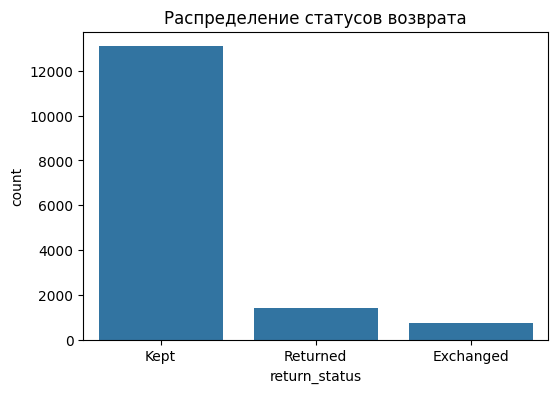

return_status
Kept         0.858990
Returned     0.091995
Exchanged    0.049016
Name: proportion, dtype: float64


In [299]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='return_status', order=df['return_status'].value_counts().index)
plt.title('Распределение статусов возврата')
plt.show()
print(df['return_status'].value_counts(normalize=True))

**Вывод:** сильный дисбаланс классов - «Kept» 86%, «Returned» 9%, «Exchanged» 5%

**Выбор метрики качества — F1-macro:**
- **F1-macro** - целевая метрика. Считает F1 для каждого класса отдельно и усредняет с равным весом. При таком дисбалансе это единственная честная метрика: плохое качество на редких классах (Returned, Exchanged) полностью отражается в итоговом значении
- **F1-weighted** отклонена: взвешивает по размеру класса, поэтому модель «всегда Kept» получит F1-weighted 0.79 без реального обучения
- **Accuracy** отклонена: dummy-модель даёт 86% - метрика вводит в заблуждение

**Приоритет: F1-macro.** Accuracy и F1-weighted выводятся дополнительно для информации

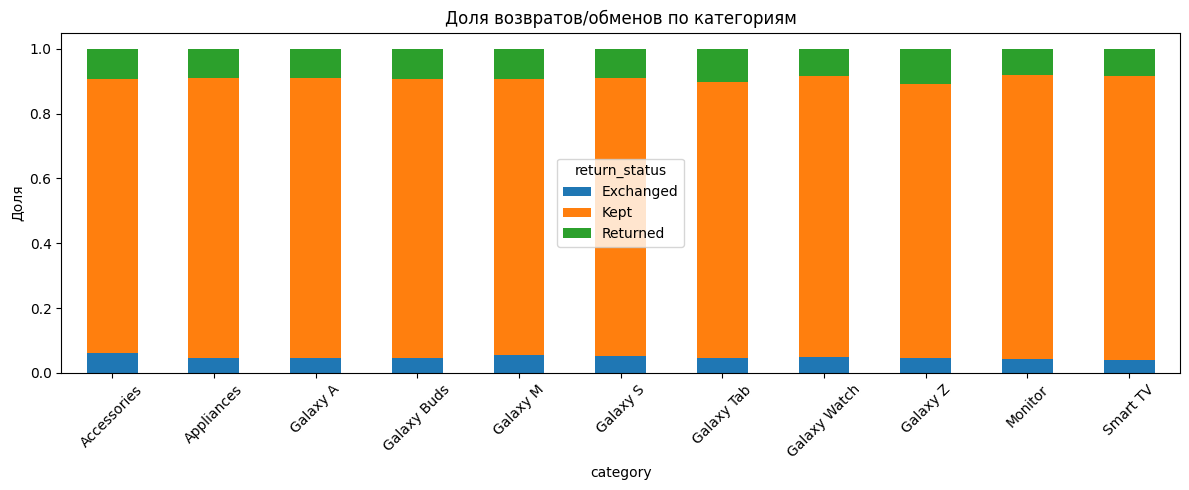

In [300]:
cross = pd.crosstab(df['category'], df['return_status'], normalize='index')
cross.plot(kind='bar', stacked=True, figsize=(12,5))
plt.title('Доля возвратов/обменов по категориям')
plt.ylabel('Доля')
plt.xticks(rotation=45)
plt.legend(title='return_status')
plt.tight_layout()
plt.show()

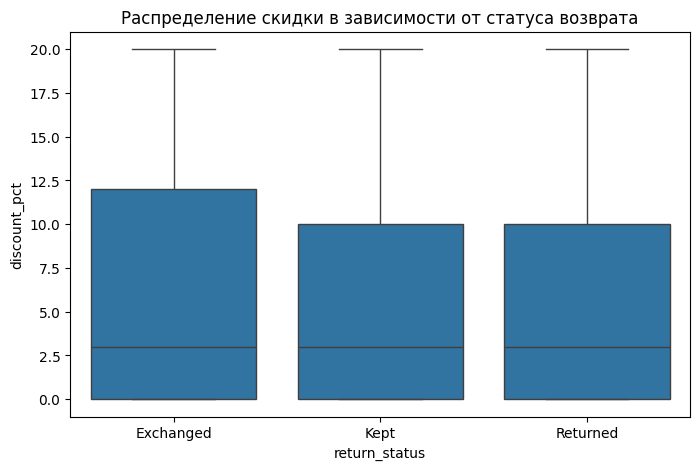

In [301]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='return_status', y='discount_pct')
plt.title('Распределение скидки в зависимости от статуса возврата')
plt.show()

**Вывод:** Распределение скидки для статусов `Exchanged`, `Kept` и `Returned` в целом схоже, но `Exchanged` верхняя граница чуть выше

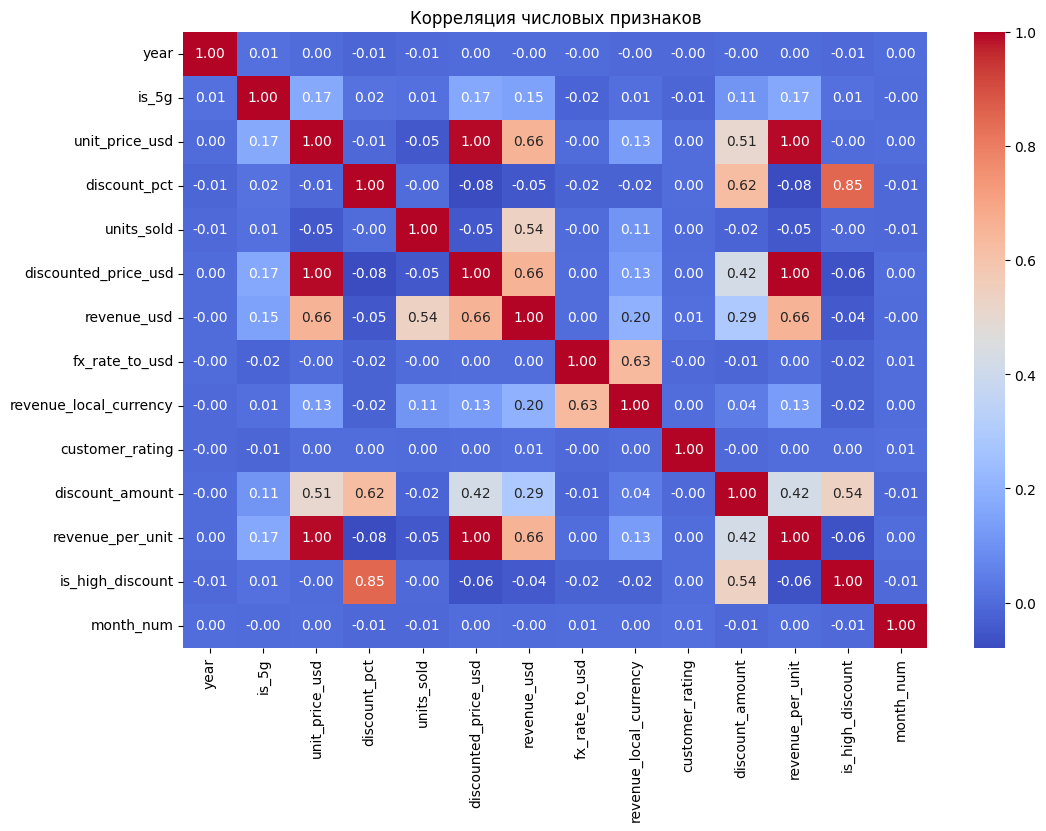

In [302]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

**Вывод:** на heatmap видно несколько групп коррелирующих признаков:
- `unit_price_usd` и `discounted_price_usd` коррелируют почти идеально (r=1.00)
  фактически дублируют друг друга
- `unit_price_usd` и `revenue_per_unit` (r=1.00) аналогично
- `discount_pct` и `is_high_discount` сильно коррелируют (r=0.85)
  `is_high_discount` является производным от `discount_pct`
- `revenue_usd` и `discounted_price_usd` (r=0.66), `units_sold` (r=0.54)
- `fx_rate_to_usd` и `revenue_local_currency` (r=0.63)

`customer_rating` и `month_num` практически не коррелируют ни с одним признаком

In [303]:
X = df.drop(columns=['return_status', 'sale_id', 'sale_date'])
y = df['return_status']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (12192, 29), Val: (1524, 29), Test: (1524, 29)


In [304]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_val_scaled = scaler.transform(X_val[numeric_features])

lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)

acc_lr = accuracy_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr, average='macro')
print(f"Logistic Regression: Accuracy={acc_lr:.4f}, F1-macro={f1_lr:.4f}")
print(classification_report(y_val, y_pred_lr))

Logistic Regression: Accuracy=0.8589, F1-macro=0.3080
              precision    recall  f1-score   support

   Exchanged       0.00      0.00      0.00        75
        Kept       0.86      1.00      0.92      1309
    Returned       0.00      0.00      0.00       140

    accuracy                           0.86      1524
   macro avg       0.29      0.33      0.31      1524
weighted avg       0.74      0.86      0.79      1524



In [305]:
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features_full = X_train.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features_full),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
print("Размерность после обработки:", X_train_processed.shape)

Размерность после обработки: (12192, 844)


In [306]:
print("Размерность X_train_processed:", X_train_processed.shape)
print("Размерность X_train числовые:", X_train[numeric_features].shape)

Размерность X_train_processed: (12192, 844)
Размерность X_train числовые: (12192, 14)


In [307]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

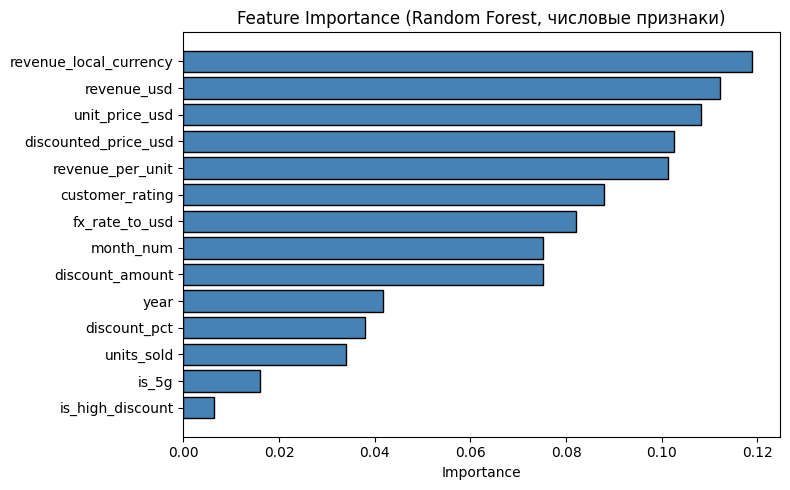

In [308]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier as _RFC

num_feats_fi = X_train.select_dtypes(include=np.number).columns.tolist()
_X_fi = X_train[num_feats_fi].fillna(X_train[num_feats_fi].median())
_y_fi = le.transform(y_train)

_rf_fi = _RFC(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
_rf_fi.fit(_X_fi, _y_fi)

_fi_df = sorted(zip(num_feats_fi, _rf_fi.feature_importances_), key=lambda x: x[1])
_names = [x[0] for x in _fi_df]
_vals  = [x[1] for x in _fi_df]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(_names, _vals, color='steelblue', edgecolor='black')
ax.set_title('Feature Importance (Random Forest, числовые признаки)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


**Вывод:** наиболее значимы финансовые признаки
`revenue_local_currency`, `revenue_usd`, `unit_price_usd`, 
`discounted_price_usd` 

In [309]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_processed, y_train_enc)
y_pred_rf = rf.predict(X_val_processed)
acc_rf = accuracy_score(y_val_enc, y_pred_rf)
f1_rf = f1_score(y_val_enc, y_pred_rf, average='macro')
print(f"RandomForest: Accuracy={acc_rf:.4f}, F1-macro={f1_rf:.4f}")

RandomForest: Accuracy=0.8589, F1-macro=0.3080


In [310]:
classes = np.unique(y_train_enc)
weights = compute_class_weight('balanced', classes=classes, y=y_train_enc)
class_weight_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weight_dict[i] for i in y_train_enc])

In [311]:
xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss')
xgb.fit(X_train_processed, y_train_enc, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_val_processed)
acc_xgb = accuracy_score(y_val_enc, y_pred_xgb)
f1_xgb = f1_score(y_val_enc, y_pred_xgb, average='macro')
print(f"XGBoost: Accuracy={acc_xgb:.4f}, F1-macro={f1_xgb:.4f}")

XGBoost: Accuracy=0.5696, F1-macro=0.3183


In [312]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1)
lgbm.fit(X_train_processed, y_train_enc)
y_pred_lgbm = lgbm.predict(X_val_processed)
acc_lgbm = accuracy_score(y_val_enc, y_pred_lgbm)
f1_lgbm = f1_score(y_val_enc, y_pred_lgbm, average='macro')
print(f"LightGBM: Accuracy={acc_lgbm:.4f}, F1-macro={f1_lgbm:.4f}")

LightGBM: Accuracy=0.6201, F1-macro=0.3126


In [313]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    random_state=RANDOM_STATE,
    verbose=0,
    auto_class_weights='Balanced'
)
cat.fit(X_train_processed, y_train_enc)
y_pred_cat = cat.predict(X_val_processed)
acc_cat = accuracy_score(y_val_enc, y_pred_cat)
f1_cat = f1_score(y_val_enc, y_pred_cat, average='macro')
print(f"CatBoost: Точность={acc_cat:.4f}, F1-macro={f1_cat:.4f}")

CatBoost: Точность=0.6804, F1-macro=0.3292


In [314]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

In [315]:
xgb_gs = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='mlogloss'
)

grid_search = GridSearchCV(
    xgb_gs, param_grid,
    scoring='f1_macro', cv=3,
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_processed, y_train_enc)

print("Лучшие параметры:", grid_search.best_params_)
best_xgb = grid_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_val_processed)
acc_best_xgb = accuracy_score(y_val_enc, y_pred_best_xgb)
f1_best_xgb = f1_score(y_val_enc, y_pred_best_xgb, average='macro')
print(f"Tuned XGBoost: Accuracy={acc_best_xgb:.4f}, F1-macro={f1_best_xgb:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Tuned XGBoost: Accuracy=0.8589, F1-macro=0.3080


In [316]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(X_train_processed)
X_val_scaled_pca = scaler_pca.transform(X_val_processed)

pca_test = PCA(random_state=RANDOM_STATE)
pca_test.fit(X_train_scaled_pca)
cumvar = np.cumsum(pca_test.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.95) + 1
print(f"Компонент для 95% дисперсии: {n_components} из {X_train_processed.shape[1]}")

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled_pca)
X_val_pca = pca.transform(X_val_scaled_pca)
print(f"Размерность после PCA: {X_train_pca.shape[1]}")

xgb_pca = XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss', **grid_search.best_params_)
xgb_pca.fit(X_train_pca, y_train_enc)
y_pred_pca = xgb_pca.predict(X_val_pca)
acc_pca = accuracy_score(y_val_enc, y_pred_pca)
f1_pca = f1_score(y_val_enc, y_pred_pca, average='macro')
print(f"XGBoost+PCA: Accuracy={acc_pca:.4f}, F1-macro={f1_pca:.4f}")

Компонент для 95% дисперсии: 644 из 844
Размерность после PCA: 644
XGBoost+PCA: Accuracy=0.8589, F1-macro=0.3080


**Вывод:** для сохранения 95% дисперсии потребовалось 644 компоненты из 844 - 
признаки слабо коррелированы между собой, PCA не даёт существенного сжатия
F1-macro с PCA (0.308) не отличается от XGBoost без PCA - уменьшение размерности 
не улучшает качество для дерево-based моделей, которые сами выбирают важные признаки

In [317]:
import warnings
warnings.filterwarnings('ignore')

In [318]:
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')),
    ('xgb', XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss')),
    ('lgbm', LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))
], voting='soft')
voting.fit(X_train_processed, y_train_enc)
y_pred_voting = voting.predict(X_val_processed)
acc_voting = accuracy_score(y_val_enc, y_pred_voting)
f1_voting = f1_score(y_val_enc, y_pred_voting, average='macro')
print(f"Voting: Accuracy={acc_voting:.4f}, F1-macro={f1_voting:.4f}")

Voting: Accuracy=0.8589, F1-macro=0.3080


In [ ]:
from sklearn.ensemble import StackingClassifier
stacking = StackingClassifier(estimators=[
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')),
    ('xgb', XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss')),
    ('lgbm', LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))
], final_estimator=LogisticRegression(random_state=RANDOM_STATE))
stacking.fit(X_train_processed, y_train_enc)
y_pred_stacking = stacking.predict(X_val_processed)
acc_stacking = accuracy_score(y_val_enc, y_pred_stacking)
f1_stacking = f1_score(y_val_enc, y_pred_stacking, average='macro')
print(f"Stacking: Accuracy={acc_stacking:.4f}, F1-macro={f1_stacking:.4f}")

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost',
              'Tuned XGBoost', 'XGBoost+PCA', 'Voting', 'Stacking'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb, acc_lgbm, acc_cat, 
                 acc_best_xgb, acc_pca, acc_voting, acc_stacking],
    'F1-macro': [f1_lr, f1_rf, f1_xgb, f1_lgbm, f1_cat, 
                 f1_best_xgb, f1_pca, f1_voting, f1_stacking]
}).sort_values('F1-macro', ascending=False)
results

,Model,Accuracy,F1-macro
4,CatBoost,0.680446,0.329225
2,XGBoost,0.569554,0.318331
3,LightGBM,0.620079,0.312616
0,Logistic Regression,0.858924,0.308036
1,RandomForest,0.858924,0.308036
5,Tuned XGBoost,0.858924,0.308036
6,XGBoost+PCA,0.858924,0.308036
7,Voting,0.858924,0.308036
8,Stacking,0.858924,0.308036


**Вывод:** лучший F1-macro показывает CatBoost (0.329) 
благодаря `auto_class_weights='Balanced'` модель лучше справляется с редкими 
классами Returned и Exchanged за счёт снижения Accuracy на доминирующем классе Kept

XGBoost и LightGBM без тюнинга показывают F1-macro 0.31-0.32 при низкой Accuracy
они также жертвуют предсказанием «Kept» ради редких классов

Большинство моделей (LogReg, RF, Tuned XGBoost, Voting, Stacking) застряли на Accuracy=0.859 и F1-macro=0.308 это признак того, что они предсказывают почти исключительно «Kept», игнорируя редкие классы

**Финальная модель: CatBoost** наилучший F1-macro на валидации

In [ ]:
X_test_processed = preprocessor.transform(X_test)

model_map = {
    'Logistic Regression': lr,
    'RandomForest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm,
    'CatBoost': cat,
    'Tuned XGBoost': best_xgb,
    'Voting': voting,
    'Stacking': stacking,
}

best_model_name = results.iloc[0]['Model']
print(f"Лучшая модель на валидации: {best_model_name}")

final_model = model_map[best_model_name]
y_pred_test = final_model.predict(X_test_processed)
test_acc = accuracy_score(y_test_enc, y_pred_test)
test_f1 = f1_score(y_test_enc, y_pred_test, average='macro')
print(f"Тестовая оценка: Accuracy={test_acc:.4f}, F1-macro={test_f1:.4f}")
print(classification_report(y_test_enc, y_pred_test, target_names=le.classes_))

Лучшая модель на валидации: CatBoost
Тестовая оценка: Accuracy=0.6857, F1-macro=0.3329
              precision    recall  f1-score   support

   Exchanged       0.05      0.07      0.06        75
        Kept       0.86      0.78      0.82      1309
    Returned       0.10      0.17      0.13       140

    accuracy                           0.69      1524
   macro avg       0.34      0.34      0.33      1524
weighted avg       0.75      0.69      0.71      1524



**Финальная оценка на тестовой выборке (CatBoost):**
- F1-macro = 0.333 - целевая метрика, тест не уступает валидации (0.329)
- Accuracy = 0.686 - намеренно снижена в пользу редких классов

**Анализ по классам:**
- `Kept` (86% данных): precision=0.86, recall=0.78 - модель хорошо находит основной класс
- `Returned` (9%): recall=0.17 - модель находит 17% реальных возвратов, что лучше чем у других моделей
- `Exchanged` (5%): recall=0.07 - самый сложный класс из-за малого числа примеров

**Вывод:** задача объективно сложная, признаки датасета слабо разделяют классы. Для улучшения результата потребовались бы дополнительные данные о поведении клиента (история покупок, детали доставки, обращения в поддержку)